# 08 — Earnings Quality

**Chain position:** … → India → Companies → Validation → `Forensics`

Notebook 06 would happily rank a company with collapsing accruals into the top 8. Nothing
in the screen asks whether the reported earnings are real. This notebook asks, and then
uses the answer twice — as a filter on the long book, and as the source of the short book.

### Three scores, and why financials get none of them

| Score | What it measures | Range |
|---|---|---|
| **Piotroski F** | Nine binary tests of year-on-year fundamental improvement | 0–9, higher better |
| **Altman Z''** | Distance from financial distress, emerging-market variant | >2.6 safe, <1.1 distress |
| **Beneish M** | Eight ratios that move when earnings are being managed | > −1.78 flags |

All three are built on working capital, gross margin, asset turns and accruals. A bank has
no meaningful current ratio and no gross margin, and its operating cash flow is a
deposit-flow number. Every score is therefore `n/a-sector` for
`config.FINANCIAL_SECTORS` — deliberately blank rather than confidently wrong, the same
mechanism notebook 06 uses.

That exclusion is not only conceptual. Measured across all 50 cached bundles: `Current
Assets` resolves for 38/38 non-financials and **1/12** financials, `Working Capital`
38/38 and 1/12, `Gross Profit` 38/38 and 1/12. Availability and validity point the same
way, and section 2 asserts the gate held.

### Never a silent partial score

Beneish needs eight ratios; Piotroski needs nine tests. If one input is missing the score
is `unavailable` and the missing component is **named**. Section 2 prints per-component
coverage so that decision is auditable rather than asserted.

### These scores carry trap #4 as well

They are computed from the *current* statements, so like the fundamental leg in notebook
07 they cannot be backtested. Section 6 reports their relationship to returns as a
**single cross-section** and labels it as such. What this notebook is actually for is the
cross-section *today*: a do-not-own list and a ranked short book.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard, quality as ql,
                 fundamentals as fnd, backtest as bt, indicators as ind, score, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

screen_path = config.OUTPUT_DIR / "nifty50_screen.csv"
if not screen_path.exists():
    raise FileNotFoundError(f"{screen_path} not found -- run notebook 06 first.")
screen = pd.read_csv(screen_path, index_col=0)
print(f"screen from notebook 06: {screen.shape[0]} names x {screen.shape[1]} columns")
print(f"statements as of        : {pd.to_datetime(screen['statement_asof']).max().date()}")

mkt v1.0.0 | run 2026-09-09 10:50 | REFRESH=False | cache=G:\stock market analysis\data\cache
screen from notebook 06: 50 names x 47 columns
statements as of        : 2026-03-31


## 1. Compute the forensic scores

The statements are already cached — notebook 06 pulled them. `q_balance` and `q_cashflow`
were fetched and never used; `q_cashflow` turns out to be **empty for 45 of the 50 names**,
so the scores run on annual statements, which is how Piotroski defined his anyway. No new
fetching happens here at all.

In [2]:
universe = dict(config.NIFTY_50)
bundles, failed = fetch.fundamentals_many(list(universe))
if failed:
    display(pd.DataFrame(failed, columns=["ticker", "reason"]))

mcaps = pd.to_numeric(screen["market_cap"], errors="coerce").to_dict()
qt = ql.quality_table(bundles, universe, mcaps)
qt["quality_score"] = ql.quality_score(qt)

n_fin = int(qt["is_financial"].sum())
print(f"scored {len(qt)} names: {len(qt) - n_fin} non-financial, "
      f"{n_fin} financial (forensics not applicable)\n")
display(qt.loc[~qt["is_financial"],
               ["sector", "piotroski_f", "altman_z", "altman_zone", "beneish_m",
                "beneish_flag", "accruals_ratio", "quality_score"]]
        .sort_values("quality_score", ascending=False).round(2))

  fundamentals: 50/50 in 0s


scored 50 names: 38 non-financial, 12 financial (forensics not applicable)



,sector,piotroski_f,altman_z,altman_zone,beneish_m,beneish_flag,accruals_ratio,quality_score
ticker,,,,,,,,
ASIANPAINT.NS,Consumer Durables,8.00,9.96,safe,-2.94,clean,-0.09,89.47
HEROMOTOCO.NS,Automobile,7.00,10.30,safe,-3.18,clean,-0.08,87.17
BHARTIARTL.NS,Telecom,7.00,3.80,safe,-3.23,clean,-0.18,72.70
ONGC.NS,Oil Gas & Fuels,7.00,4.89,safe,-2.87,clean,-0.09,72.70
TRENT.NS,Consumer Services,5.00,7.96,safe,-3.11,clean,-0.09,72.37
HCLTECH.NS,Information Technology,7.00,10.32,safe,-2.46,clean,-0.03,71.38
TECHM.NS,Information Technology,8.00,9.13,safe,-2.52,clean,-0.03,71.05
INFY.NS,Information Technology,5.00,11.49,safe,-2.74,clean,-0.04,70.39
TATASTEEL.NS,Metals & Mining,7.00,4.21,safe,-2.91,clean,-0.08,69.41


## 2. Coverage and the sector gate

The verification the design calls for: per-score provenance, per-component coverage, and an
assertion that the `n/a-sector` count equals the financials count **exactly**. A financial
that slipped through would carry a Piotroski score built on a current ratio that does not
exist — a number that looks fine and means nothing.

In [3]:
cov = ql.coverage_report(qt)
display(cov)
display(ql.assert_sector_gate(qt))

print("Per-component coverage -- a score is only reported when every component resolved:\n")
for which, label in (("beneish", "Beneish M (8 ratios)"),
                     ("piotroski", "Piotroski F (9 tests)"),
                     ("altman", "Altman Z (4 ratios)")):
    cc = ql.component_coverage(qt, which)
    if cc.empty:
        continue
    worst = cc["coverage_%"].min()
    print(f"{label}: {len(cc)} components, minimum coverage {worst:.1f}% "
          f"of {int(cc['eligible'].iloc[0])} eligible names")
    if worst < 100:
        display(cc[cc["coverage_%"] < 100])

unavailable = qt[(~qt["is_financial"]) & (qt["missing_components"].str.len() > 0)]
if len(unavailable):
    print(f"\n{len(unavailable)} name(s) could not be scored in full:")
    display(unavailable[["missing_components"]])
else:
    print("\nEvery non-financial resolved every component of every score.")

,computed,n/a-sector,unavailable,non_financials,coverage_of_eligible_%
score,,,,,
piotroski_f,38,12,0,38,100.00
altman_z,38,12,0,38,100.00
beneish_m,38,12,0,38,100.00
accruals_ratio,38,12,0,38,100.00


,financials,scores_checked,result
0,12,4,every score is n/a-sector for exactly the fina...


Per-component coverage -- a score is only reported when every component resolved:

Beneish M (8 ratios): 8 components, minimum coverage 100.0% of 38 eligible names


Piotroski F (9 tests): 9 components, minimum coverage 100.0% of 38 eligible names
Altman Z (4 ratios): 5 components, minimum coverage 100.0% of 38 eligible names

Every non-financial resolved every component of every score.


### A note on the row names

The common expectation is that Beneish is hard on free data because `Gross PPE`, `SG&A`
and `Depreciation` are inconsistently named. Measured across all 50 cached bundles, that
turns out to be **wrong for this universe**: the names are *unobvious* — Yahoo files
`Selling General And Administration` (not "Administrative") and puts depreciation on the
income statement as `Reconciled Depreciation` — but they are consistent, resolving for
38/38 non-financials.

What did bite was subtler, and is fixed in `fundamentals.series_for`: the candidate-row
list was resolving to the *first* row carrying any data rather than the *best-covered*
one. `Net Income Common Stockholders` exists for CIPLA.NS and WIPRO.NS with a single
non-null period while `Net Income` has four, so those two names were silently truncated to
one period — which also left their earnings CAGR unavailable in notebook 06's screen. Six
such cases exist across the Nifty 50.

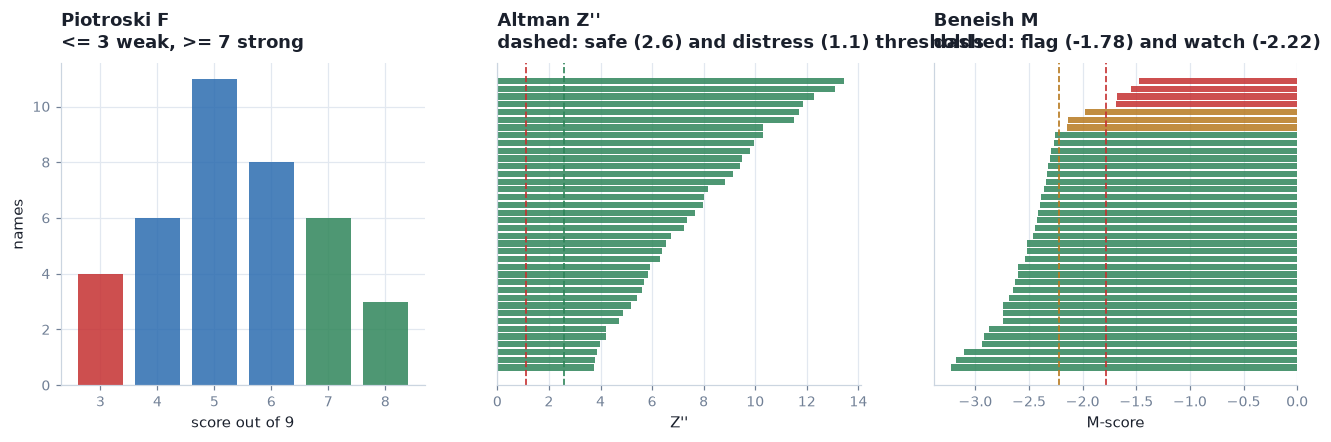

Altman zones: {'safe': 38}
   Every name sits in the safe zone. That is a real result about the universe,
   not a strong signal: Altman Z is a bankruptcy predictor and the Nifty 50 is
   India's 50 largest listed companies. It has essentially no discriminating
   power here, and is carried for the cross-check rather than the ranking.
Beneish flags: {'clean': 31, 'manipulation-flag': 4, 'watch': 3}


In [4]:
nf = qt[~qt["is_financial"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
a = axes[0]
counts = nf["piotroski_f"].value_counts().sort_index()
a.bar(counts.index.astype(int).astype(str), counts.values, alpha=0.85,
      color=[viz.NEG if int(i) <= ql.PIOTROSKI_WEAK else
             (viz.POS if int(i) >= ql.PIOTROSKI_STRONG else viz.PALETTE[0])
             for i in counts.index])
viz.title(a, "Piotroski F", f"<= {ql.PIOTROSKI_WEAK} weak, >= {ql.PIOTROSKI_STRONG} strong")
a.set_xlabel("score out of 9"); a.set_ylabel("names")

a = axes[1]
z = nf["altman_z"].dropna().sort_values()
a.barh(range(len(z)), z.values, alpha=0.85,
       color=[viz.NEG if v <= ql.ALTMAN_DISTRESS else
              (viz.POS if v >= ql.ALTMAN_SAFE else viz.PALETTE[5]) for v in z.values])
a.axvline(ql.ALTMAN_SAFE, color=viz.POS, ls="--", lw=1.1)
a.axvline(ql.ALTMAN_DISTRESS, color=viz.NEG, ls="--", lw=1.1)
a.set_yticks([]); a.grid(axis="y", visible=False)
viz.title(a, "Altman Z''", "dashed: safe (2.6) and distress (1.1) thresholds")
a.set_xlabel("Z''")

a = axes[2]
m = nf["beneish_m"].dropna().sort_values()
a.barh(range(len(m)), m.values, alpha=0.85,
       color=[viz.NEG if v > ql.BENEISH_FLAG else
              (viz.PALETTE[5] if v > ql.BENEISH_WATCH else viz.POS) for v in m.values])
a.axvline(ql.BENEISH_FLAG, color=viz.NEG, ls="--", lw=1.1)
a.axvline(ql.BENEISH_WATCH, color=viz.PALETTE[5], ls="--", lw=1.1)
a.set_yticks([]); a.grid(axis="y", visible=False)
viz.title(a, "Beneish M", "dashed: flag (-1.78) and watch (-2.22)")
a.set_xlabel("M-score")
viz.save(fig, "08_forensic_distributions"); plt.show()

print(f"Altman zones: {nf['altman_zone'].value_counts().to_dict()}")
if (nf["altman_zone"] == "safe").all():
    print("   Every name sits in the safe zone. That is a real result about the universe,")
    print("   not a strong signal: Altman Z is a bankruptcy predictor and the Nifty 50 is")
    print("   India's 50 largest listed companies. It has essentially no discriminating")
    print("   power here, and is carried for the cross-check rather than the ranking.")
print(f"Beneish flags: {nf['beneish_flag'].value_counts().to_dict()}")

## 3. Red flags and the do-not-own list

A name lands on the do-not-own list if it fails a **hard** forensic test: Beneish above the
manipulation threshold, Altman in the distress zone, or Piotroski at or below 3. This is
independent of what the screen thinks of it — that is the point of a filter.

In [5]:
dno = ql.do_not_own(qt)
if len(dno):
    print(f"{len(dno)} name(s) fail a hard forensic test:\n")
    for t, r in dno.iterrows():
        in_screen = int(screen.loc[t, "rank"]) if t in screen.index else None
        print(f"  {t.replace('.NS', ''):14s} {r['sector']:24s} "
              f"screen rank {in_screen}")
        for f in ql.red_flags(r):
            print(f"       - {f}")
    display(dno[["sector", "piotroski_f", "altman_z", "beneish_m", "accruals_ratio"]].round(2))
else:
    print("No name fails a hard forensic test.")

top8 = screen.nsmallest(config.TOP_N_DEEP_DIVE, "rank").index
overlap = [t for t in top8 if t in dno.index]
print(f"\nOf notebook 06's top {config.TOP_N_DEEP_DIVE}, "
      f"{len(overlap)} appear on the do-not-own list: {overlap if overlap else 'none'}")

7 name(s) fail a hard forensic test:

  BAJAJ-AUTO     Automobile               screen rank 1
       - Beneish M -1.69 -- above the manipulation threshold
       - accruals +12.4% of assets -- earnings ahead of cash
  BEL            Capital Goods            screen rank 25
       - Beneish M -1.68 -- above the manipulation threshold
       - accruals +10.6% of assets -- earnings ahead of cash
  CIPLA          Healthcare               screen rank 33
       - Piotroski 3/9 -- fundamentals deteriorating
  DRREDDY        Healthcare               screen rank 48
       - Piotroski 3/9 -- fundamentals deteriorating
  ETERNAL        Consumer Services        screen rank 13
       - Beneish M -1.47 -- above the manipulation threshold
  POWERGRID      Power                    screen rank 38
       - Piotroski 3/9 -- fundamentals deteriorating
  TMPV           Automobile               screen rank 47
       - Piotroski 3/9 -- fundamentals deteriorating
       - Beneish M -1.55 -- above the manipulat

,sector,piotroski_f,altman_z,beneish_m,accruals_ratio
ticker,,,,,
BAJAJ-AUTO.NS,Automobile,5.00,8.15,-1.69,0.12
BEL.NS,Capital Goods,6.00,9.80,-1.68,0.11
CIPLA.NS,Healthcare,3.00,13.43,-2.40,-0.00
DRREDDY.NS,Healthcare,3.00,9.42,-2.52,-0.03
ETERNAL.NS,Consumer Services,4.00,8.02,-1.47,-0.01
POWERGRID.NS,Power,3.00,4.00,-2.45,-0.09
TMPV.NS,Automobile,3.00,3.86,-1.55,0.18



Of notebook 06's top 8, 1 appear on the do-not-own list: ['BAJAJ-AUTO.NS']


In [6]:
keep = [t for t in screen.index if t not in dno.index]
filtered = screen.loc[keep].join(
    qt[["piotroski_f", "altman_z", "altman_zone", "beneish_m", "beneish_flag",
        "accruals_ratio", "quality_score"]])
filtered = filtered.sort_values("composite", ascending=False)
filtered["rank_filtered"] = range(1, len(filtered) + 1)
filtered.index.name = "ticker"

out_path = config.OUTPUT_DIR / "nifty50_screen_filtered.csv"
filtered.round(4).to_csv(out_path)
print(f"Wrote {out_path}  ({filtered.shape[0]} rows x {filtered.shape[1]} columns)")
print(f"   {len(screen)} screened -> {len(filtered)} after the forensic filter "
      f"({len(dno)} removed)")

print(f"\nTop {config.TOP_N_DEEP_DIVE} after filtering:")
display(filtered.head(config.TOP_N_DEEP_DIVE)[
    ["sector", "composite", "fund_pct", "tech_pct", "piotroski_f", "beneish_m",
     "accruals_ratio", "quality_score"]].round(2))

Wrote G:\stock market analysis\outputs\nifty50_screen_filtered.csv  (43 rows x 55 columns)
   50 screened -> 43 after the forensic filter (7 removed)

Top 8 after filtering:


,sector,composite,fund_pct,tech_pct,piotroski_f,beneish_m,accruals_ratio,quality_score
ticker,,,,,,,,
KOTAKBANK.NS,Financial Services,84.00,80.00,88.00,NaN,NaN,NaN,NaN
COALINDIA.NS,Oil Gas & Fuels,82.00,86.00,78.00,4.00,-2.74,-0.04,56.91
ADANIPORTS.NS,Services,82.00,78.00,86.00,7.00,-2.33,-0.05,58.88
ICICIBANK.NS,Financial Services,78.00,84.00,72.00,NaN,NaN,NaN,NaN
JSWSTEEL.NS,Metals & Mining,78.00,74.00,82.00,8.00,-2.26,-0.01,52.63
TITAN.NS,Consumer Durables,77.00,56.00,98.00,6.00,-2.29,-0.01,44.41
EICHERMOT.NS,Automobile,76.00,88.00,64.00,5.00,-2.60,0.02,55.92
HEROMOTOCO.NS,Automobile,74.00,98.00,50.00,7.00,-3.18,-0.08,87.17


**Why the filter lives here and not in notebook 06.** Filtering inside 06 would need 08's
output, and 08 reads 06's screen — a cycle. Keeping the filter downstream preserves the
run-in-order contract: 06 writes `nifty50_screen.csv`, 08 writes
`nifty50_screen_filtered.csv`, and notebook 10 reads the filtered file.

## 4. The short book

The mandate is long/short market-neutral, so forensics is not only a filter here — it is
half the alpha source.

A short needs **both** halves to fail. Bad accounting alone is a stock that can stay
expensive for years; a weak tape alone is a stock that is merely cheap. The ranking
averages forensic weakness and screen weakness on a common 0–100 scale, so a name has to
fail on both to reach the top, and a sector cap stops the short book becoming one sector
bet inverted.

,short_rank,sector,short_score,forensic_weakness,screen_weakness,composite,quality_score,piotroski_f,beneish_m,accruals_ratio
ticker,,,,,,,,,,
TMPV.NS,1,Automobile,93.30,94.40,92.10,26.00,5.60,3.00,-1.50,0.20
DRREDDY.NS,2,Healthcare,74.50,53.00,96.10,16.00,47.00,3.00,-2.50,-0.00
HINDUNILVR.NS,3,FMCG,73.40,67.80,78.90,35.00,32.20,5.00,-2.30,0.10
TATACONSUM.NS,4,FMCG,72.50,49.00,96.10,16.00,51.00,6.00,-2.30,-0.00
WIPRO.NS,5,Information Technology,72.50,55.60,89.50,27.00,44.40,4.00,-2.30,-0.00
GRASIM.NS,6,Construction Materials,67.80,81.60,53.90,47.00,18.40,5.00,-2.10,0.00
M&M.NS,7,Automobile,67.10,68.40,65.80,41.00,31.60,5.00,-2.30,0.00
POWERGRID.NS,8,Power,65.30,59.50,71.10,39.00,40.50,3.00,-2.40,-0.10



Why each name is here:
  1. TMPV           Automobile               Piotroski 3/9 -- fundamentals deteriorating; Beneish M -1.55 -- above the manipulation threshold; accruals +18.2% of assets -- earnings ahead of cash
  2. DRREDDY        Healthcare               Piotroski 3/9 -- fundamentals deteriorating
  3. HINDUNILVR     FMCG                     no hard flag -- ranked on the combination, not a single failure
  4. TATACONSUM     FMCG                     no hard flag -- ranked on the combination, not a single failure
  5. WIPRO          Information Technology   no hard flag -- ranked on the combination, not a single failure
  6. GRASIM         Construction Materials   Beneish M -2.14 -- watch band
  7. M&M            Automobile               no hard flag -- ranked on the combination, not a single failure
  8. POWERGRID      Power                    Piotroski 3/9 -- fundamentals deteriorating


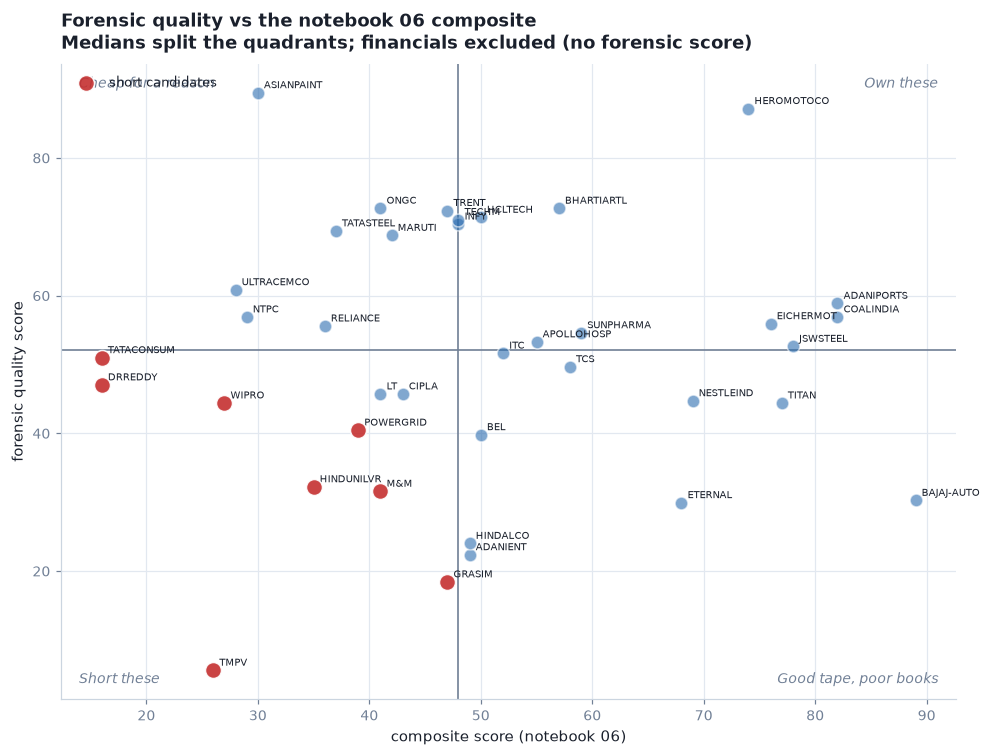

In [7]:
shorts = ql.short_candidates(qt, screen, n=config.TOP_N_DEEP_DIVE,
                             max_per_sector=config.MAX_PER_SECTOR)
if len(shorts):
    display(shorts[["short_rank", "sector", "short_score", "forensic_weakness",
                    "screen_weakness", "composite", "quality_score", "piotroski_f",
                    "beneish_m", "accruals_ratio"]].round(1))
    print("\nWhy each name is here:")
    for t, r in shorts.iterrows():
        fl = r["flags"] or "no hard flag -- ranked on the combination, not a single failure"
        print(f"  {int(r['short_rank'])}. {t.replace('.NS', ''):14s} {r['sector']:24s} {fl}")
else:
    print("No eligible short candidates.")

fig, ax = plt.subplots(figsize=(10.5, 7.5))
plot = qt[~qt["is_financial"]].join(screen[["composite"]], how="inner").dropna(
    subset=["quality_score", "composite"])
is_short = plot.index.isin(shorts.index)
ax.scatter(plot.loc[~is_short, "composite"], plot.loc[~is_short, "quality_score"],
           s=70, color=viz.PALETTE[0], alpha=0.6, edgecolor="white", zorder=3)
ax.scatter(plot.loc[is_short, "composite"], plot.loc[is_short, "quality_score"],
           s=110, color=viz.NEG, alpha=0.9, edgecolor="white", zorder=4,
           label="short candidates")
for t, r in plot.iterrows():
    ax.annotate(t.replace(".NS", ""), (r["composite"], r["quality_score"]),
                fontsize=6.8, xytext=(4, 3), textcoords="offset points")
ax.axvline(plot["composite"].median(), color=viz.MUTED, lw=1.1)
ax.axhline(plot["quality_score"].median(), color=viz.MUTED, lw=1.1)
for txt, xy, ha, va in [("Own these", (0.98, 0.98), "right", "top"),
                        ("Cheap for a reason", (0.02, 0.98), "left", "top"),
                        ("Short these", (0.02, 0.02), "left", "bottom"),
                        ("Good tape, poor books", (0.98, 0.02), "right", "bottom")]:
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=9, color=viz.MUTED,
            style="italic", ha=ha, va=va)
viz.title(ax, "Forensic quality vs the notebook 06 composite",
          "Medians split the quadrants; financials excluded (no forensic score)")
ax.set_xlabel("composite score (notebook 06)"); ax.set_ylabel("forensic quality score")
ax.legend(loc="upper left", fontsize=8.5)
viz.save(fig, "08_quality_vs_composite"); plt.show()

## 5. Does quality add anything the screen does not already have?

If the forensic score simply re-states the composite, it is redundant. The direct test is
their rank correlation across the cross-section — a question that can be answered honestly
**today**, without any backtest and without any look-ahead.

In [8]:
j = qt[~qt["is_financial"]].join(
    screen[["composite", "fund_pct", "tech_pct"]], how="inner").dropna(
    subset=["quality_score", "composite"])

corr_rows = []
for col in ("composite", "fund_pct", "tech_pct"):
    corr_rows.append({
        "vs": col,
        "spearman": round(float(j["quality_score"].corr(j[col], method="spearman")), 3),
        "pearson": round(float(j["quality_score"].corr(j[col])), 3),
        "n": len(j),
    })
display(pd.DataFrame(corr_rows).set_index("vs"))

rho = float(j["quality_score"].corr(j["composite"], method="spearman"))
se = 1 / np.sqrt(len(j) - 1)
if abs(rho) < 2 * se:
    reading = ("statistically indistinguishable from zero -- the forensic score is "
               "close to orthogonal to the composite, so it adds information rather "
               "than restating it")
elif rho > 0:
    reading = ("positively correlated -- the screen already partly rewards what the "
               "forensics measure, so the marginal information is smaller than it looks")
else:
    reading = ("negatively correlated -- the screen systematically favours names the "
               "forensics dislike, which is exactly the case for a filter")
print(f"\nSpearman rank correlation with the composite: {rho:+.3f} "
      f"(n={len(j)}, SE about {se:.2f})")
print(f"Reading: {reading}")

,spearman,pearson,n
vs,,,
composite,0.03,0.04,38
fund_pct,0.27,0.29,38
tech_pct,-0.24,-0.23,38



Spearman rank correlation with the composite: +0.033 (n=38, SE about 0.16)
Reading: statistically indistinguishable from zero -- the forensic score is close to orthogonal to the composite, so it adds information rather than restating it


### The single-cross-section caveat

The next cell measures how the forensic ranking relates to returns **since the statements
were published**. Two limits, both fatal to treating it as evidence:

1. **It is one observation.** One date, ~38 names, rank-IC standard error ≈ 1/√37 ≈ 0.16.
   A reading of 0.2 is one standard error from zero. Notebook 07 built its conclusions on
   the t-statistic of an IC series across 107 rebalances; there is no such series here.
2. **It cannot be extended backwards.** Trap #4 — there are no point-in-time statements,
   so there is no way to build the history that would make this a real test.

It is reported because a number with its limits attached is more useful than silence, and
because knowing the sign is worth something. It is not a validation.

window            : 2026-06-01 -> 2026-09-09 (72 sessions)
names             : 38
rank IC           : -0.113
standard error    : 0.164  ->  0.7 standard errors from zero

ONE observation. Not evidence. See the caveat above.


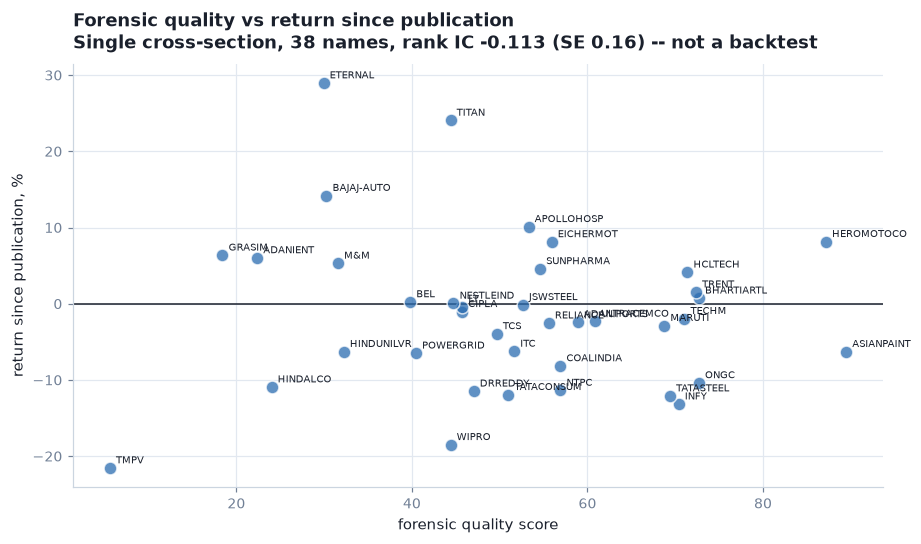

In [9]:
stmt_date = pd.to_datetime(screen["statement_asof"], errors="coerce").max()
# Indian FY-March results are filed roughly six weeks after year end; start the window
# after that so the scores were genuinely public for the period being measured.
pub_date = stmt_date + pd.Timedelta(days=60)

px_frames, _ = fetch.price_histories(list(j.index), period="1y", verbose=False)
px = align.align_to_calendar(fetch.close_frame(px_frames), calendar="NSE")
window = px.loc[pub_date:]

if len(window) > 5:
    since = (window.iloc[-1] / window.iloc[0] - 1) * 100
    pair = pd.concat([j["quality_score"], since.rename("ret")], axis=1).dropna()
    ic_one = float(pair["quality_score"].corr(pair["ret"], method="spearman"))
    se_one = 1 / np.sqrt(len(pair) - 1)
    print(f"window            : {window.index[0].date()} -> {window.index[-1].date()} "
          f"({len(window)} sessions)")
    print(f"names             : {len(pair)}")
    print(f"rank IC           : {ic_one:+.3f}")
    print(f"standard error    : {se_one:.3f}  ->  {abs(ic_one) / se_one:.1f} standard errors from zero")
    print(f"\nONE observation. Not evidence. See the caveat above.")

    fig, ax = plt.subplots(figsize=(9.5, 5))
    ax.scatter(pair["quality_score"], pair["ret"], s=70, color=viz.PALETTE[0],
               alpha=0.75, edgecolor="white", zorder=3)
    for t, r in pair.iterrows():
        ax.annotate(t.replace(".NS", ""), (r["quality_score"], r["ret"]),
                    fontsize=6.8, xytext=(4, 3), textcoords="offset points")
    ax.axhline(0, color=viz.INK, lw=1)
    viz.title(ax, "Forensic quality vs return since publication",
              f"Single cross-section, {len(pair)} names, rank IC {ic_one:+.3f} "
              f"(SE {se_one:.2f}) -- not a backtest")
    ax.set_xlabel("forensic quality score"); ax.set_ylabel("return since publication, %")
    viz.save(fig, "08_quality_vs_return"); plt.show()
else:
    ic_one, se_one = float("nan"), float("nan")
    print("Not enough sessions since publication to measure anything.")

## 6. What this hands forward

In [10]:
payload = {
    "signal": (f"{len(dno)} do-not-own, {len(shorts)} short candidates, "
               f"{len(filtered)} names pass"),
    "score": round(float(nf["quality_score"].mean()), 2),
    "as_of": str(stmt_date.date()),
    "universe": len(qt),
    "non_financials_scored": int(len(nf)),
    "financials_excluded": n_fin,
    "coverage_%": {str(i): float(r) for i, r in cov["coverage_of_eligible_%"].items()},
    "do_not_own": {t: ql.red_flags(dno.loc[t]) for t in dno.index},
    "short_candidates": {
        t: {"rank": int(r["short_rank"]), "sector": r["sector"],
            "short_score": round(float(r["short_score"]), 1),
            "quality_score": round(float(r["quality_score"]), 1),
            "composite": round(float(r["composite"]), 1),
            "piotroski_f": (None if not np.isfinite(r["piotroski_f"]) else float(r["piotroski_f"])),
            "beneish_m": (None if not np.isfinite(r["beneish_m"]) else round(float(r["beneish_m"]), 2))}
        for t, r in shorts.iterrows()},
    "beneish_flags": {str(k): int(v) for k, v in nf["beneish_flag"].value_counts().items()},
    "altman_zones": {str(k): int(v) for k, v in nf["altman_zone"].value_counts().items()},
    "quality_vs_composite_spearman": round(float(rho), 3),
    "single_cross_section_ic": (None if not np.isfinite(ic_one) else round(float(ic_one), 3)),
    "in_sample_only": ("forensic scores come from current statements -- trap #4 applies, "
                       "no backtest is possible"),
    "exports": ["outputs/nifty50_screen_filtered.csv"],
}
dashboard.append("08_earnings_quality", payload)
display(dashboard.summary())

print("\nTo notebook 09 and 10:")
print(f"  long candidates  : outputs/nifty50_screen_filtered.csv "
      f"({len(filtered)} names, {len(dno)} removed)")
print(f"  short candidates : {len(shorts)} names, "
      f"{shorts['sector'].nunique() if len(shorts) else 0} sectors")
print("\nNotebook 09 reads both lists and asks who else is already in these trades --")
print("a crowded short is where you get squeezed. It also emits the lot sizes that")
print("notebook 10 needs before it can size a short leg at all (trap #5).")

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:20:08
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54



To notebook 09 and 10:
  long candidates  : outputs/nifty50_screen_filtered.csv (43 names, 7 removed)
  short candidates : 8 names, 6 sectors

Notebook 09 reads both lists and asks who else is already in these trades --
a crowded short is where you get squeezed. It also emits the lot sizes that
notebook 10 needs before it can size a short leg at all (trap #5).
